In [3]:
import numpy as np
import pandas as pd
from math import radians, sin, cos, sqrt, atan2
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append(str(Path("..") / "src"))
from data_loader import load_data # type: ignore

GEOJSON_PATH = Path("../data/clean/neighbourhoods.geojson")
OUTPUT_DIR = Path("../output/spatial")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="darkgrid")
FIGSIZE = (12, 7)
DPI = 300

### Data checks

In [4]:
data = load_data()
train, val, test = data["train"]["listings"], data["val"]["listings"], data["test"]["listings"]
print(train.shape, val.shape, test.shape)

(5868, 44) (1483, 44) (1853, 44)


In [5]:
# Leaving only Geo columns and targets
SPATIAL_COLS = ["listing_id", "neighborhood", "neighborhood_group", "latitude", "longitude", "price", "log_price",]
train_geo = train[SPATIAL_COLS].copy()
print(train_geo.shape)

(5868, 7)


In [6]:
print(train_geo[["latitude", "longitude", "neighborhood", "neighborhood_group"]].isna().sum(), "\n")

mapping_check = train_geo.groupby("neighborhood")["neighborhood_group"].nunique()
print("neighborhoods mapping to more than 1 group:", (mapping_check > 1).sum())

print("exact same coordinates:", train_geo.duplicated(subset=["latitude","longitude"]).sum())

latitude              0
longitude             0
neighborhood          0
neighborhood_group    0
dtype: int64 

neighborhoods mapping to more than 1 group: 0
exact same coordinates: 523


In [7]:
neighborhoods = gpd.read_file(GEOJSON_PATH)
print(neighborhoods.columns)
print("duplicate neighbourhood rows in geojson:", neighborhoods["neighborhood"].duplicated().sum())

Index(['neighborhood', 'neighborhood_group', 'geometry'], dtype='str')
duplicate neighbourhood rows in geojson: 1


In [8]:
dup_mask = neighborhoods.duplicated(subset="neighborhood", keep=False)
neighborhoods[dup_mask]

,neighborhood,neighborhood_group,geometry
11,NaN,NaN,"MULTIPOLYGON (((13.61659 52.58154, 13.61458 52..."
12,NaN,NaN,"MULTIPOLYGON (((13.61668 52.57868, 13.60703 52..."


In [9]:
# Dropping irrelevant polygons, probably just mapping anomalies
neighborhoods = neighborhoods[neighborhoods["neighborhood"].notna()].reset_index(drop=True)
print("duplicate neighbourhood rows in geojson:", neighborhoods["neighborhood"].duplicated().sum())

duplicate neighbourhood rows in geojson: 0


In [10]:
json_names = set(neighborhoods["neighborhood"])
df_names = set(train_geo["neighborhood"])
print("in data, not in geojson:", df_names - json_names)
print("in geojson, not in data:", json_names - df_names)

in data, not in geojson: set()
in geojson, not in data: set()


### Creating dataframe and describing

In [11]:
# Listings as points

# Transforming the lat/long columns into an actual geometry column, 
# the same CRS as GPS and the geojson (degrees, not meters)
gdf = gpd.GeoDataFrame(train_geo, geometry=gpd.points_from_xy(train_geo["longitude"], train_geo["latitude"]), crs="EPSG:4326")

# Convert to a Berlin-specific metric CRS (meters, not degrees)
# Needed for anything involving real distance
gdf_metric = gdf.to_crs("EPSG:25833")


# Neighborhood polygons

neighborhoods_metric = neighborhoods.to_crs("EPSG:25833")

groups_metric = neighborhoods.dissolve(by="neighborhood_group", as_index=False).to_crs("EPSG:25833")

In [12]:
train_geo["price"].describe()

count    5868.000000
mean      125.280845
std        80.108544
min        10.000000
25%        70.000000
50%       103.000000
75%       159.000000
max       582.000000
Name: price, dtype: float64

In [13]:
train_geo.groupby("neighborhood_group")["price"].median().sort_values()

neighborhood_group
Reinickendorf                69.0
Marzahn - Hellersdorf        75.5
Steglitz - Zehlendorf        85.0
Treptow - Köpenick           85.0
Spandau                      88.0
Neukölln                     92.0
Tempelhof - Schöneberg       95.0
Lichtenberg                  98.5
Friedrichshain-Kreuzberg    103.0
Charlottenburg-Wilm.        104.0
Pankow                      113.0
Mitte                       120.5
Name: price, dtype: float64

### Plotting

In [14]:
def save_fig(fig, name):
    path = OUTPUT_DIR / f"{name}.png"
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")

Saved: ../output/spatial/scatter_basic.png


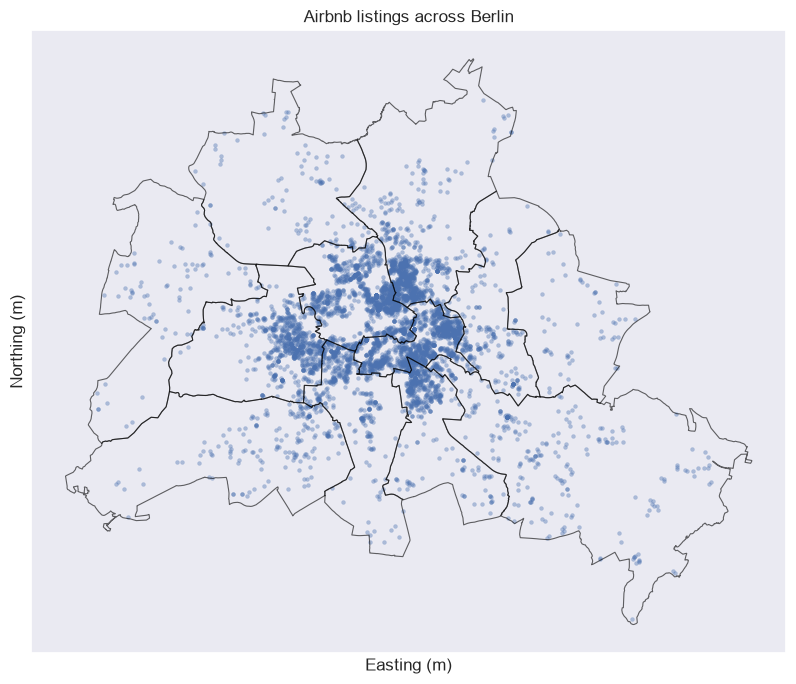

In [15]:
fig, ax = plt.subplots(figsize=FIGSIZE)

groups_metric.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.6)

sns.scatterplot(x=gdf_metric.geometry.x, y=gdf_metric.geometry.y, s=8, alpha=0.4, edgecolor=None, ax=ax)

ax.set_aspect("equal"); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Airbnb listings across Berlin")

plt.tight_layout()
save_fig(fig, "scatter_basic")
plt.show()

Saved: ../output/spatial/scatter_basemap.png


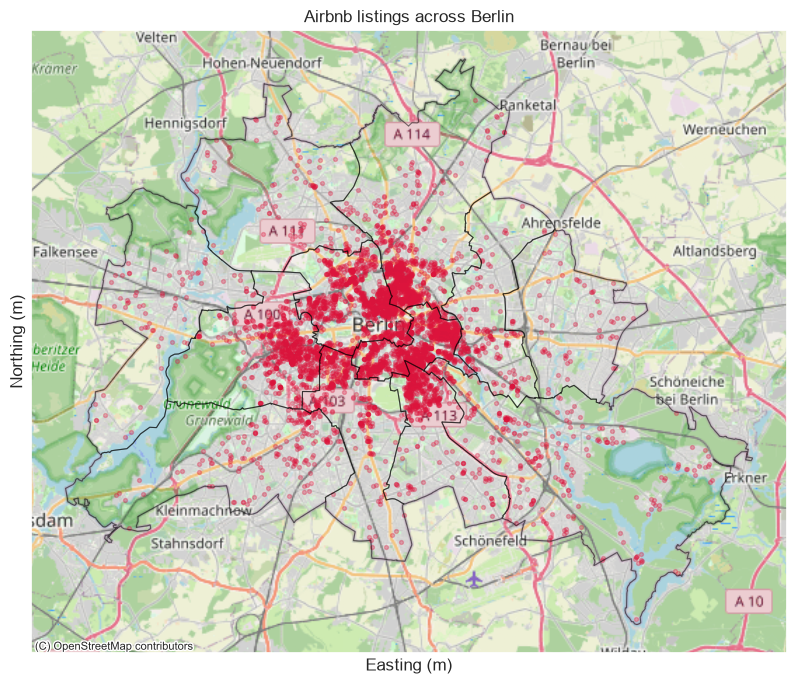

In [16]:
gdf_web = gdf.to_crs(epsg=3857)
groups_web = groups_metric.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=FIGSIZE)

groups_web.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.5)

ax.scatter(gdf_web.geometry.x, gdf_web.geometry.y, s=8, alpha=0.3, color="crimson", edgecolor=None,)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik) # type: ignore

ax.set_aspect("equal")
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Airbnb listings across Berlin")

plt.tight_layout()
save_fig(fig, "scatter_basemap")
plt.show()

Saved: ../output/spatial/scatter_price.png


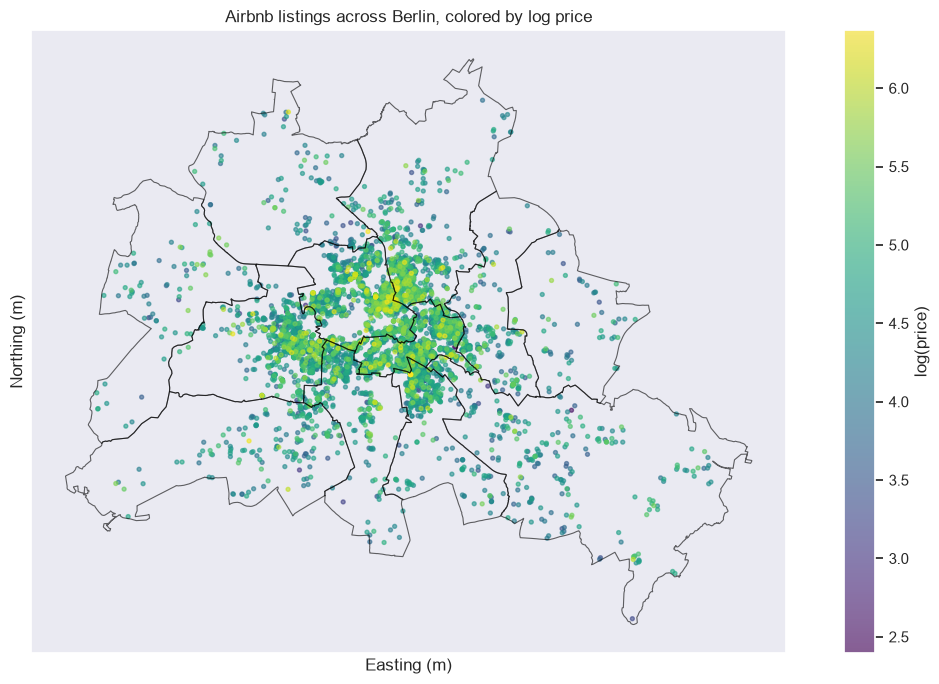

In [17]:
# sorting to see the bigger prices better
plot_df = gdf_metric.sort_values("log_price")

fig, ax = plt.subplots(figsize=FIGSIZE)

groups_metric.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.6)

scatter = ax.scatter(plot_df.geometry.x, plot_df.geometry.y, c=plot_df["log_price"], cmap="viridis", s=8, alpha=0.6, edgecolor=None)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("log(price)")

ax.set_aspect("equal"); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Airbnb listings across Berlin, colored by log price")

plt.tight_layout()
save_fig(fig, "scatter_price")
plt.show()

In [18]:
group_price = train_geo.groupby("neighborhood_group")["log_price"].median()
neigh_price = train_geo.groupby("neighborhood")["log_price"].median()

groups_plot = groups_metric.merge(group_price.rename("median_log_price"), on="neighborhood_group", how="left")
neigh_plot = neighborhoods_metric.merge(neigh_price.rename("median_log_price"), on="neighborhood", how="left")

Saved: ../output/spatial/price_per_neighborhood_group.png


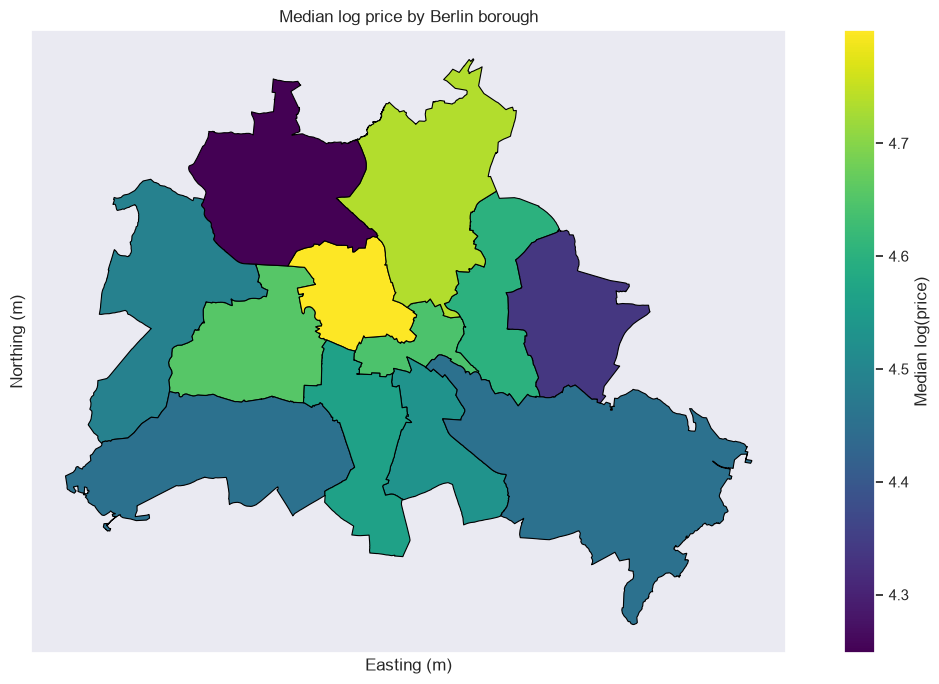

In [19]:
fig, ax = plt.subplots(figsize=FIGSIZE)

groups_plot.plot(column="median_log_price", cmap="viridis", edgecolor="black", linewidth=0.8, legend=True, legend_kwds={"label": "Median log(price)"}, ax=ax)

ax.set_aspect("equal"); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Median log price by Berlin borough")

plt.tight_layout()
save_fig(fig, "price_per_neighborhood_group")
plt.show()

Saved: ../output/spatial/price_per_neighborhood.png


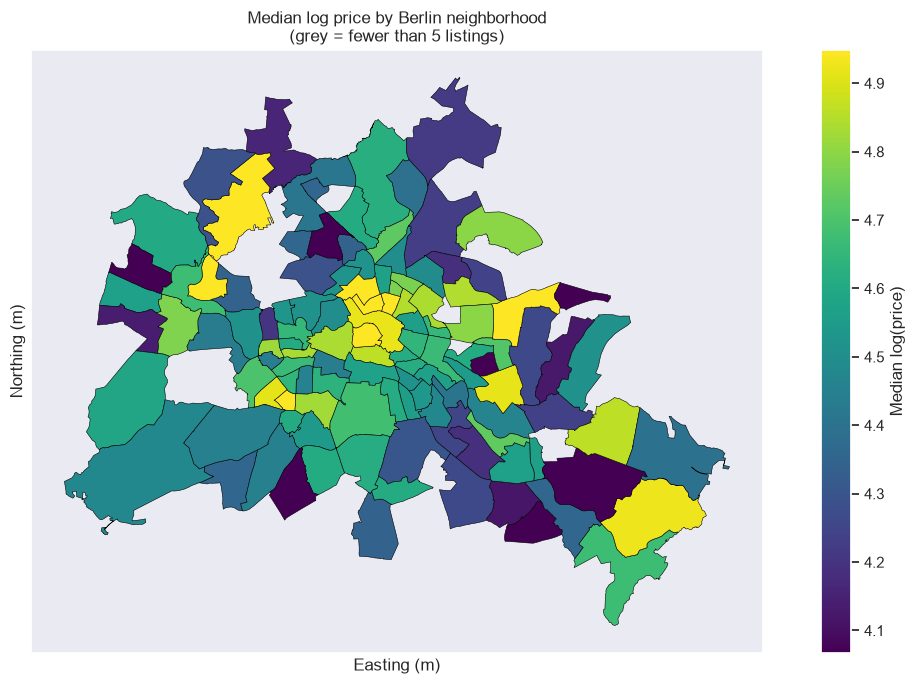

In [20]:
fig, ax = plt.subplots(figsize=FIGSIZE)

# Listings per neighborhood
neigh_count = train_geo.groupby("neighborhood").size()
neigh_plot["listing_count"] = neigh_plot["neighborhood"].map(neigh_count)

# Neighborhoods with too few listings get their median blanked out
MIN_LISTINGS = 5
neigh_plot_masked = neigh_plot.copy()
low_sample = neigh_plot_masked["listing_count"].fillna(0) < MIN_LISTINGS
neigh_plot_masked.loc[low_sample, "median_log_price"] = np.nan

# clipping so the neighs with single bnbs with extreme prices to not stretch the plot
reliable_prices = neigh_plot_masked.loc[~low_sample, "median_log_price"]
p_low, p_high = reliable_prices.quantile([0.05, 0.95])

neigh_plot_masked.plot(column="median_log_price", cmap="viridis", vmin=p_low, vmax=p_high, edgecolor="black", linewidth=0.4, legend=True, legend_kwds={"label": "Median log(price)"}, ax=ax)

ax.set_aspect("equal")
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title(f"Median log price by Berlin neighborhood\n(grey = fewer than {MIN_LISTINGS} listings)")

plt.tight_layout()
save_fig(fig, "price_per_neighborhood")
plt.show()

Saved: ../output/spatial/density.png


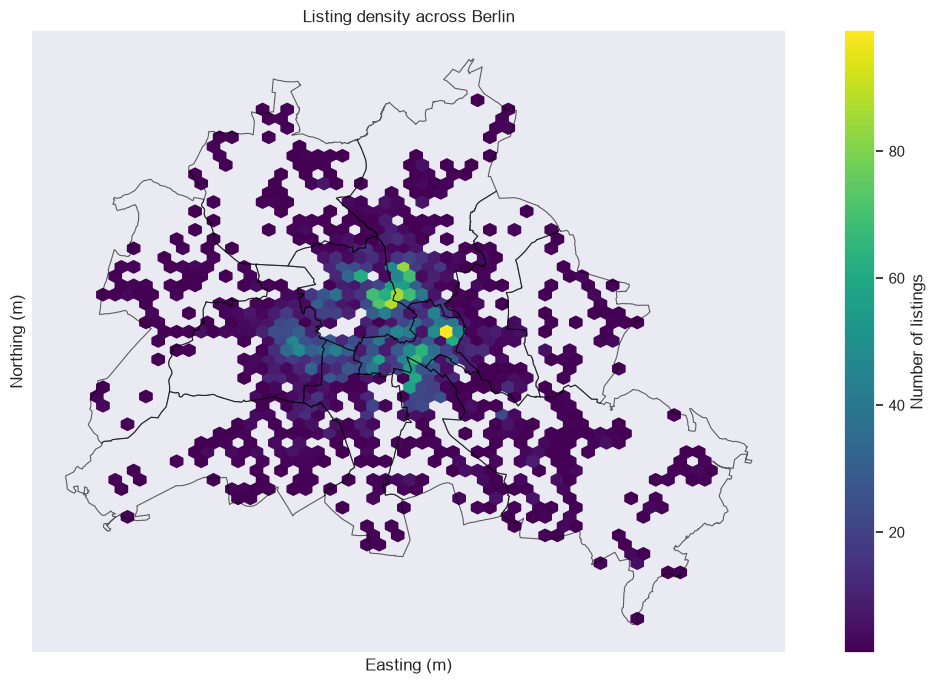

In [21]:
fig, ax = plt.subplots(figsize=FIGSIZE)

groups_metric.boundary.plot(ax=ax, color="black", linewidth=0.8, alpha=0.6)

hb = ax.hexbin(gdf_metric.geometry.x, gdf_metric.geometry.y, gridsize=50, cmap="viridis", mincnt=1)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("Number of listings")

ax.set_aspect("equal")
ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_title("Listing density across Berlin")

plt.tight_layout()
save_fig(fig, "density")
plt.show()

Saved: ../output/spatial/boxplot_by_group.png


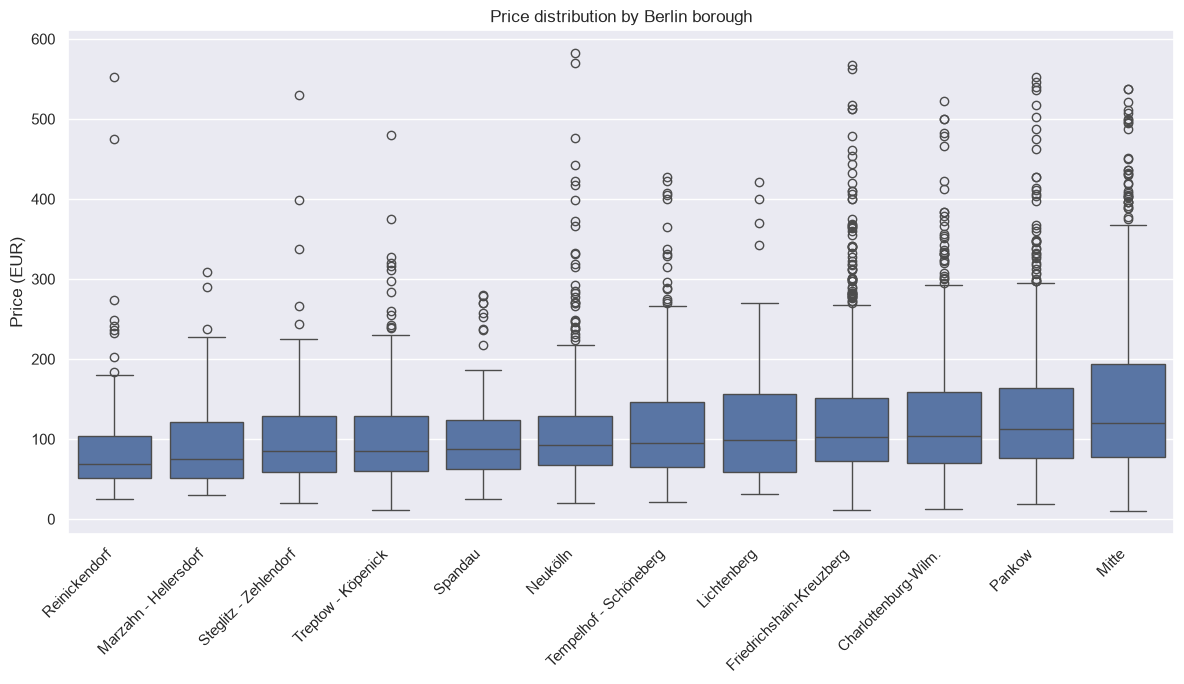

In [22]:
order = train_geo.groupby("neighborhood_group")["price"].median().sort_values().index

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.boxplot(data=train_geo, x="neighborhood_group", y="price", order=order, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Price (EUR)")
ax.set_title("Price distribution by Berlin borough")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
save_fig(fig, "boxplot_by_group")
plt.show()

Saved: ../output/spatial/barplot_count_by_group.png


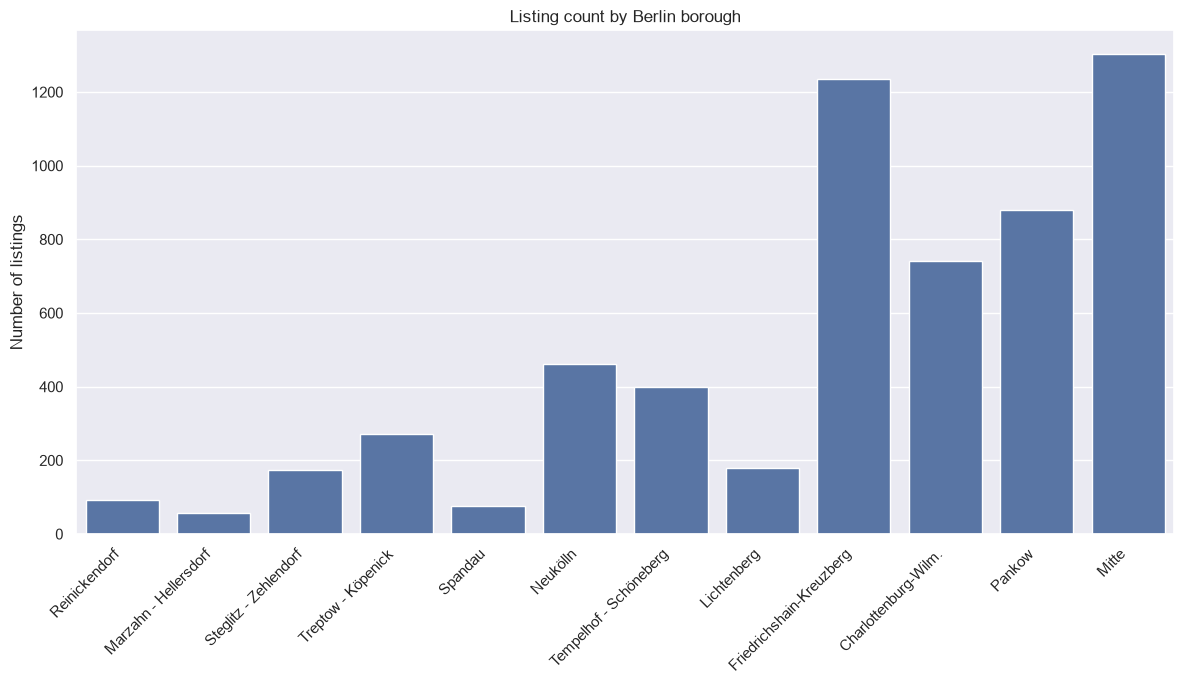

In [23]:
order = train_geo.groupby("neighborhood_group")["price"].median().sort_values().index
counts = train_geo["neighborhood_group"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=FIGSIZE)

sns.barplot(x=counts.index, y=counts.values, order=order, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Number of listings")
ax.set_title("Listing count by Berlin borough")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
save_fig(fig, "barplot_count_by_group")
plt.show()

In [24]:
CENTER_LAT, CENTER_LON = 52.520833, 13.409444  # Berlin TV tower

def haversine(lat, lon, lat0=CENTER_LAT, lon0=CENTER_LON):
    R = 6371
    lat, lon, lat0, lon0 = map(radians, [lat, lon, lat0, lon0])
    dlat, dlon = lat - lat0, lon - lon0
    a = sin(dlat / 2) ** 2 + cos(lat0) * cos(lat) * sin(dlon / 2) ** 2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

In [ ]:
train_geo["dist_to_center"] = train_geo.apply(lambda r: haversine(r["latitude"], r["longitude"]), axis=1)
print(train_geo[["dist_to_center", "log_price"]].corr())
# negative correlation. further from center -- cheaper

                dist_to_center  log_price
dist_to_center        1.000000  -0.167716
log_price            -0.167716   1.000000
